# Boston House Price Prediction
**Dataset:** Boston Housing Dataset (StatLib/UCI)

**Model:** Linear Regression with StandardScaler

# **1.IMPORTING LIBRARIES**

In [1]:
#importing python libraries
import     pandas     as     pd
import   numpy   as   np

#data visualization libraries
import   matplotlib.pyplot   as   plt
import   seaborn   as   sns
%matplotlib   inline
sns.set_style(  'darkgrid'  )

#preprocessing and model selection
from   sklearn.model_selection   import   train_test_split
from   sklearn.preprocessing   import   StandardScaler

#import Machine Learning Models
from   sklearn.linear_model   import   LinearRegression
from      sklearn      import      metrics

print('Libraries imported successfully!')

Libraries imported successfully!


# **2.DATA COLLECTION**

> ⚠️ **Note:** `sklearn.datasets.load_boston` was removed in scikit-learn v1.2 due to ethical concerns. This project loads the dataset directly from a public URL — no download needed.

In [2]:
print('='*60)
print('LOADING DATASET')
print('='*60)

# load_boston() was removed in sklearn v1.2 - loading from public URL instead
DATA_URL = 'https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv'

try:
    data=pd.read_csv(DATA_URL)
    data.columns=[c.upper() for c in data.columns]
    data.rename(columns={'MEDV':'PRICE'}, inplace=True)
    print('Dataset loaded successfully!')
except Exception as e:
    print(f'Error occurred while loading the dataset: {e}')
    print('Trying local file boston_housing.csv')
    data=pd.read_csv('boston_housing.csv')
    data.columns=[c.upper() for c in data.columns]
    data.rename(columns={'MEDV':'PRICE'}, inplace=True)

print(f'\nDataset shape: {data.shape}')

LOADING DATASET
Dataset loaded successfully!

Dataset shape: (506, 14)


In [3]:
data.head(6)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7


In [4]:
print(f'Columns:{list(data.columns)}')
print(f'Shape of the dataset: {data.shape}')

Columns:['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'PRICE']
Shape of the dataset: (506, 14)


# **3.EXPLORING DATA ANALYSIS**

In [5]:
# Viewing the data statistics
data.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [6]:
# Check for missing values
print(f'Missing values:\n{data.isnull().sum()}')
print('\nNo missing values.' if data.isnull().sum().sum() == 0 else '\nMissing values found!')

Missing values:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64

No missing values.


In [7]:
print(f'Data types:\n{data.dtypes}')

Data types:
CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX          int64
PTRATIO    float64
B          float64
LSTAT      float64
PRICE      float64
dtype: object


In [8]:
# Identifying the unique number of values in the dataset
print(f'Unique values per column:\n{data.nunique()}')

Unique values per column:
CRIM       504
ZN          26
INDUS       76
CHAS         2
NOX         81
RM         446
AGE        356
DIS        412
RAD          9
TAX         66
PTRATIO     46
B          357
LSTAT      455
PRICE      229
dtype: int64


In [9]:
#Key column insights
print(f'RAD unique values : {data["RAD"].nunique()}')
print(f'CHAS unique values : {data["CHAS"].nunique()} (binary = 1 if tract bounds Charles River)')
print(f'ZN unique values : {data["ZN"].nunique()}')
print(f'\nTarget (PRICE) stats:')
print(f' Min  : ${data["PRICE"].min()}k')
print(f' Max  : ${data["PRICE"].max()}k')
print(f' Mean : ${data["PRICE"].mean():.2f}k')
print(f' Median : ${data["PRICE"].median()}k')

RAD unique values : 9
CHAS unique values : 2 (binary = 1 if tract bounds Charles River)
ZN unique values : 26

Target (PRICE) stats:
 Min  : $5.0k
 Max  : $50.0k
 Mean : $22.53k
 Median : $21.2k


# **4.DATA VISUALIZATION**

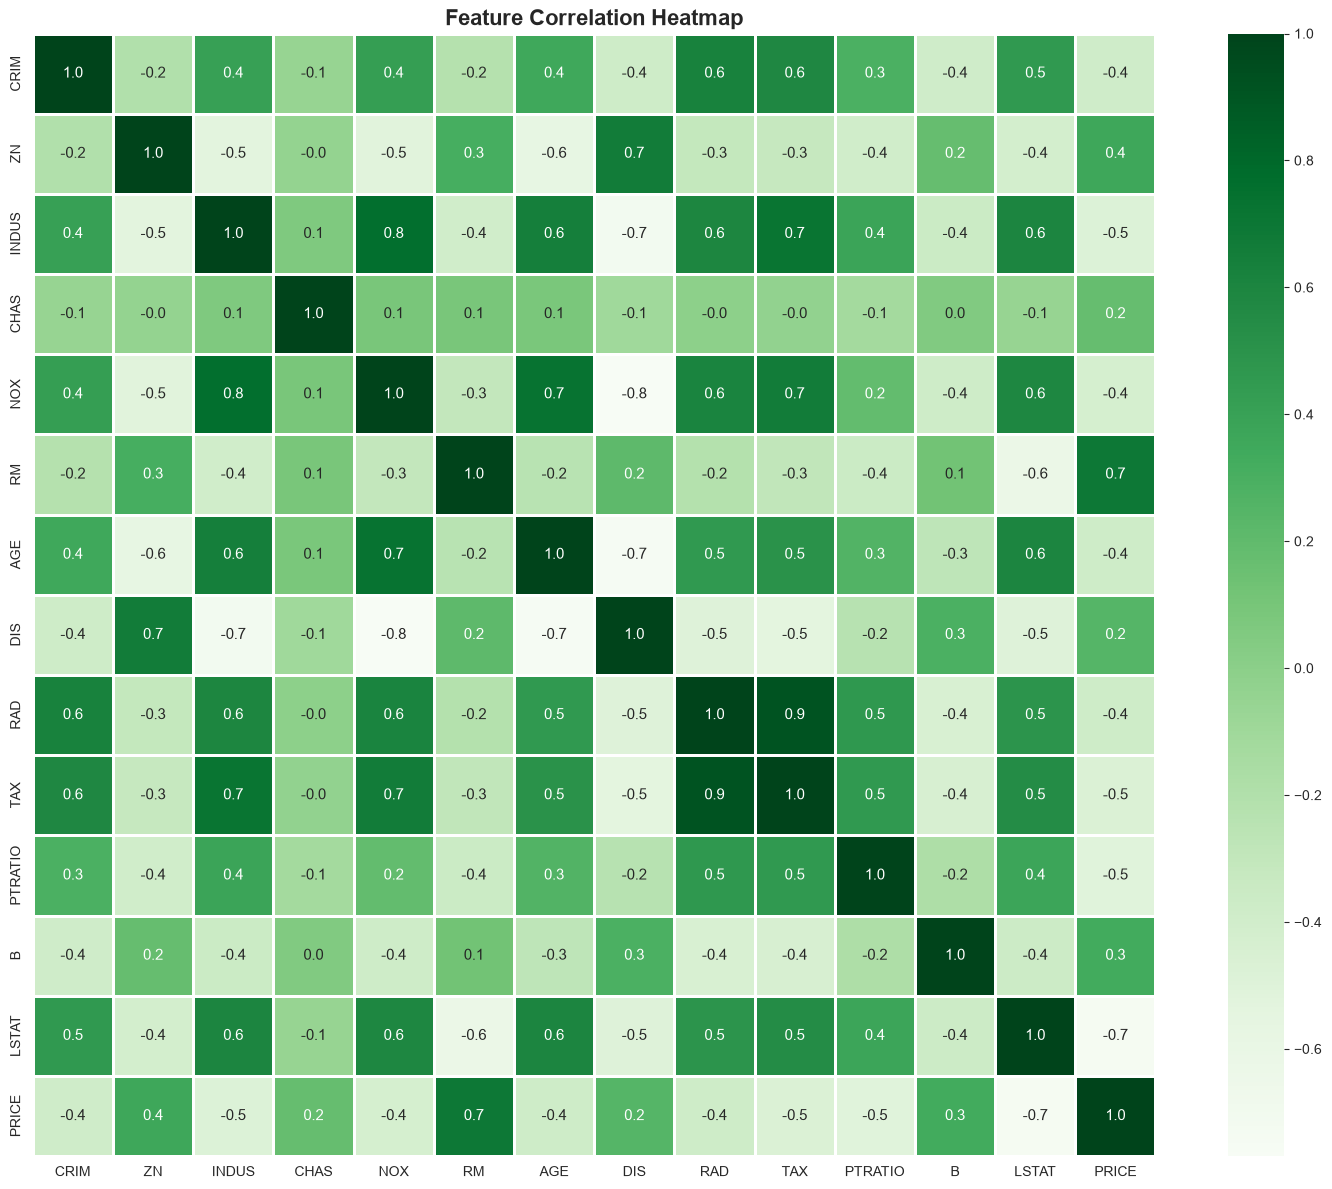

In [10]:
# Plotting the heatmap of correlation between features
corr = data.corr()
plt.figure(figsize=(15,12))
sns.heatmap(corr, cbar=True, square= True, fmt='.1f', annot=True, annot_kws={'size':11}, linewidth=1,cmap='Greens')
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

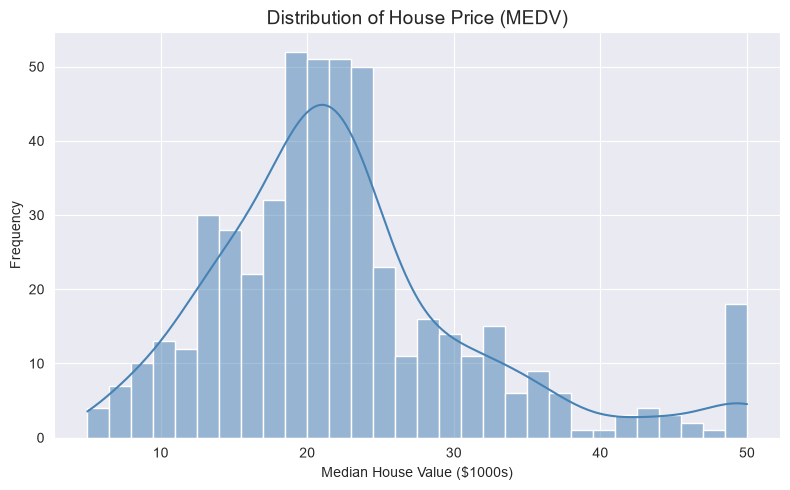

In [11]:
#Price distribution
plt.figure(figsize=(8,5))
sns.histplot(data['PRICE'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of House Price (MEDV)', fontsize=14)
plt.xlabel('Median House Value ($1000s)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

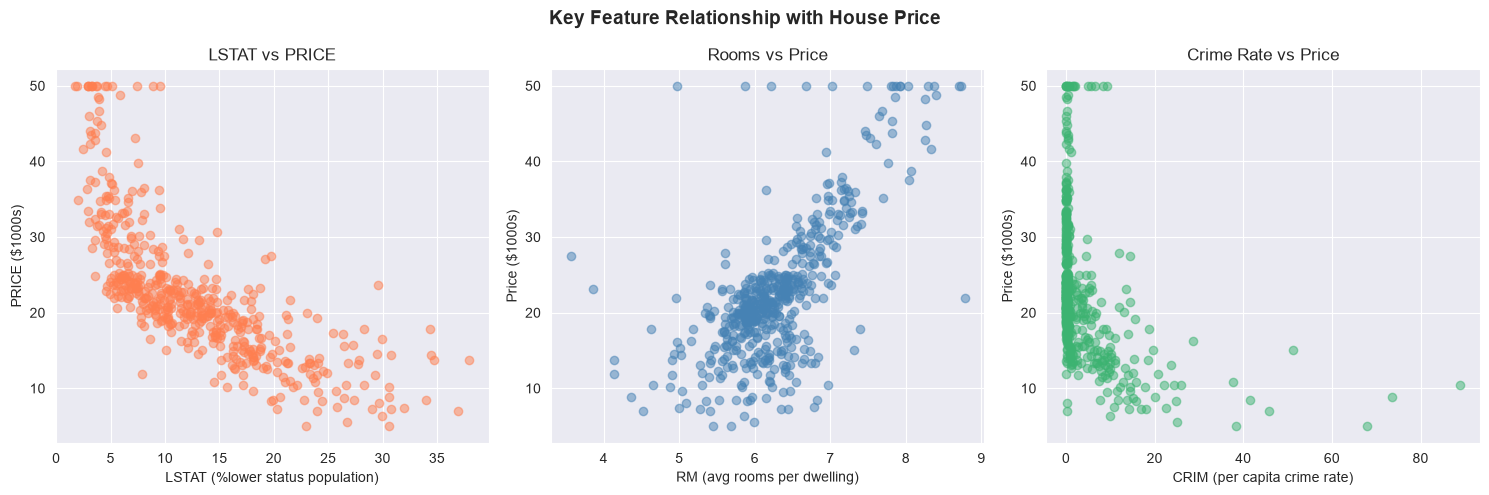

In [12]:
#Key feature relationships with PRICE
fig,axes=plt.subplots(1,3,figsize=(15,5))

#LSTAT - Strongest negative correlation
axes[0].scatter(data['LSTAT'],data['PRICE'],alpha=0.5,color='coral')
axes[0].set_xlabel('LSTAT (%lower status population)')
axes[0].set_ylabel('PRICE ($1000s)')
axes[0].set_title('LSTAT vs PRICE')

# RM - Strongest positive correlation
axes[1].scatter(data['RM'],data['PRICE'],alpha=0.5,color='steelblue')
axes[1].set_xlabel('RM (avg rooms per dwelling)')
axes[1].set_ylabel('Price ($1000s)')
axes[1].set_title('Rooms vs Price')

#CRIM -crime rate impact
axes[2].scatter(data['CRIM'],data['PRICE'],alpha=0.5,color='mediumseagreen')
axes[2].set_xlabel('CRIM (per capita crime rate)')
axes[2].set_ylabel('Price ($1000s)')
axes[2].set_title('Crime Rate vs Price')

plt.suptitle('Key Feature Relationship with House Price',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\Vanshika\AppData\Local\Temp\ipykernel_368092\165044323.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='CHAS',y='PRICE',data=data,palette=['#3498db','#e74c3c'])


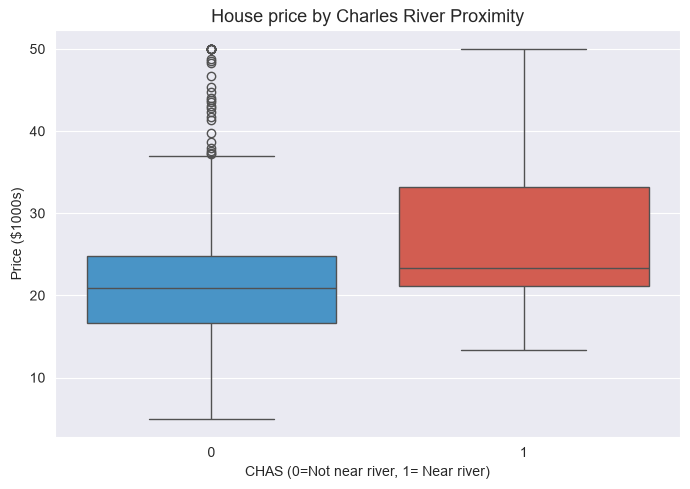

In [13]:
#Boxplot - price by CHAS (river proximity)
plt.figure(figsize=(7,5))
sns.boxplot(x='CHAS',y='PRICE',data=data,palette=['#3498db','#e74c3c'])
plt.title('House price by Charles River Proximity', fontsize=13)
plt.xlabel('CHAS (0=Not near river, 1= Near river)')
plt.ylabel('Price ($1000s)')
plt.tight_layout()
plt.show()

# **5.MODEL IMPLEMENTATION**

In [14]:
# Spliting target variable and independent variables
X = data.drop(['PRICE'], axis = 1)
y = data['PRICE']

print(f'Features shape: {X.shape}')
print(f'Target shape   :{y.shape}')
print(f'\nFeatures: {list(X.columns)}')

Features shape: (506, 13)
Target shape   :(506,)

Features: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']


In [15]:
# Splitting to training and testing data
# 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state = 4)
print(f'Train size : {X_train.shape[0]} samples')
print(f'Test size: {X_test.shape[0]} samples')

Train size : 354 samples
Test size: 152 samples


### **Performing Feature Standard Scaler**
It removes the mean and scale it to unit variance.

In [16]:
#fir ONLY on train set, transform both
# Fitting on test set = data leakage (test data influences the scaler)
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)   # fit + transform on train
X_test_scaled = sc.transform(X_test)     #transform only on test

print('StandardScaler applied - mean removed, unit variance.')
print(f'Scaler mean (first 5 features): {sc.mean_[:5].round(4)}')

StandardScaler applied - mean removed, unit variance.
Scaler mean (first 5 features): [ 3.8229 10.8743 11.05    0.0508  0.5566]


Model Implementing

In [17]:
lm = LinearRegression()
# Train the model using the training sets
lm.fit(X_train_scaled, y_train)

print(f'Model trained successfully.')
print(f'Intercept: {lm.intercept_:.4f}')

Model trained successfully.
Intercept: 22.1223


In [18]:
#Feature Coefficients Table
coeff_df=pd.DataFrame({'Feature':X.columns,'Coefficient':lm.coef_}).sort_values('Coefficient',ascending=False)

print('Feature Coefficients (sorted):')
print(coeff_df.to_string(index=False))
print('\nPositive=increases price | Negative =decreases price')

Feature Coefficients (sorted):
Feature  Coefficient
    RAD     2.889719
     RM     2.167312
     ZN     1.286103
   CHAS     1.031086
      B     0.854242
  INDUS    -0.060704
    AGE    -0.095307
   CRIM    -1.086731
    NOX    -1.688782
PTRATIO    -1.745614
    TAX    -2.392723
    DIS    -3.326271
  LSTAT    -3.708423

Positive=increases price | Negative =decreases price


# **6.MODEL EVALUATION**

In [19]:
def evaluate(y_true,y_pred,split_name,n_features):
    r2=metrics.r2_score(y_true,y_pred)
    adj_r2=1-(1-r2)*(len(y_true)-1)/(len(y_true)-n_features-1)
    mae=metrics.mean_absolute_error(y_true,y_pred)
    mse=metrics.mean_squared_error(y_true,y_pred)
    rmse=np.sqrt(mse)
    print(f'\n{split_name} Results:')
    print(f'  R²          : {r2:.4f}')
    print(f'  Adjusted R² : {adj_r2:.4f}')
    print(f'  MAE         : {mae:.4f}  (avg error in $1000s)')
    print(f'  MSE         : {mse:.4f}')
    print(f'  RMSE        : {rmse:.4f}  (std of prediction error)')
    return {'R2': r2, 'Adj_R2': adj_r2, 'MAE': mae, 'MSE': mse, 'RMSE': rmse}

y_train_pred=lm.predict(X_train_scaled)
y_test_pred=lm.predict(X_test_scaled)

train_metrics=evaluate(y_train,y_train_pred,'TRAIN',X_train_scaled.shape[1])
test_metrics=evaluate(y_test,y_test_pred,'TEST',X_test_scaled.shape[1])

gap=abs(train_metrics['R2']-test_metrics['R2'])
print(f'\nR² gap (train - test): {gap:.4f}')
print('✓ Model is not overfitting.' if gap < 0.05 else '⚠ Possible overfitting detected.')


TRAIN Results:
  R²          : 0.7466
  Adjusted R² : 0.7369
  MAE         : 3.0899  (avg error in $1000s)
  MSE         : 19.0737
  RMSE        : 4.3673  (std of prediction error)

TEST Results:
  R²          : 0.7122
  Adjusted R² : 0.6851
  MAE         : 3.8590  (avg error in $1000s)
  MSE         : 30.0540
  RMSE        : 5.4822  (std of prediction error)

R² gap (train - test): 0.0344
✓ Model is not overfitting.


# **7.PREDICTION VISUALISATIONS**

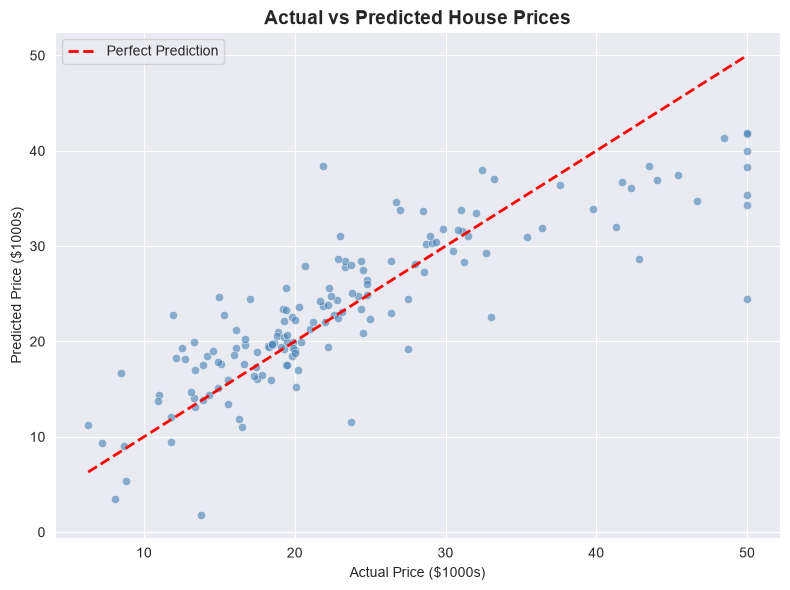

Saved: actual_vs_predicted.png
Points close to red line = accurate predictions.


In [20]:
# Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6, color='steelblue',
            edgecolors='white', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price ($1000s)')
plt.ylabel('Predicted Price ($1000s)')
plt.title('Actual vs Predicted House Prices', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()
print('Saved: actual_vs_predicted.png')
print('Points close to red line = accurate predictions.')

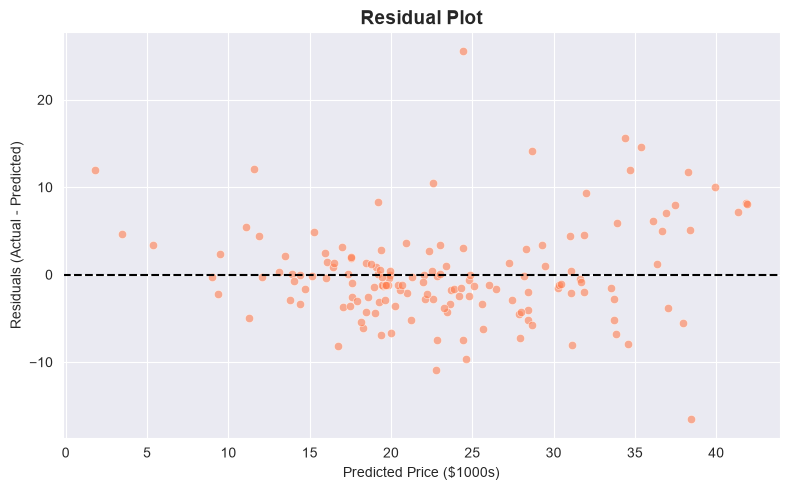

Saved: residual_plot.png
Good model: residuals randomly scattered around 0 with no clear pattern.


In [21]:
# Residual plot
residuals = y_test - y_test_pred
plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred, residuals, alpha=0.6, color='coral',
            edgecolors='white', linewidth=0.5)
plt.axhline(y=0, color='black', linestyle='--', lw=1.5)
plt.xlabel('Predicted Price ($1000s)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('residual_plot.png', dpi=150)
plt.show()
print('Saved: residual_plot.png')
print('Good model: residuals randomly scattered around 0 with no clear pattern.')

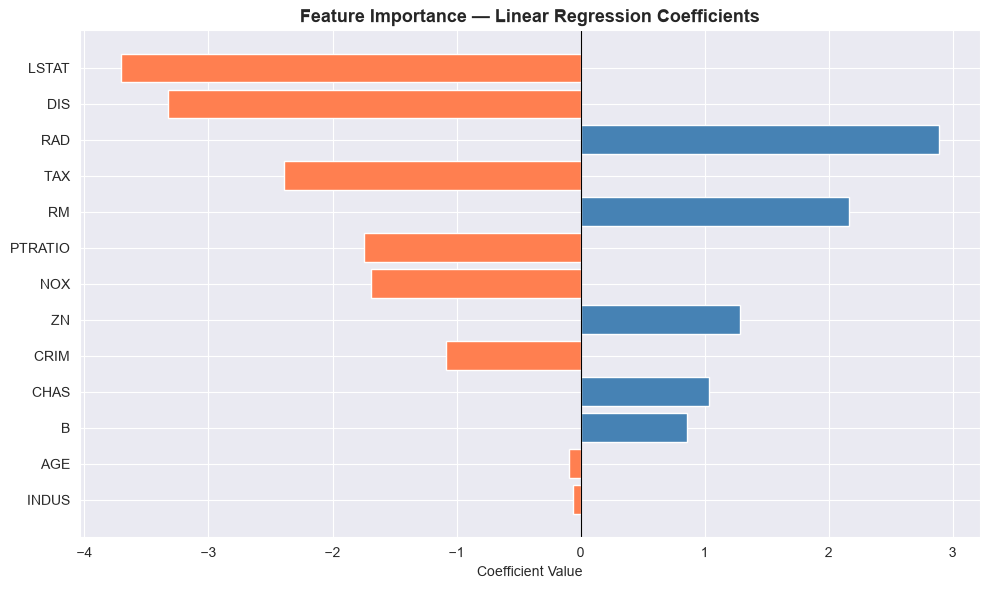

Blue = positive impact on price | Red = negative impact on price


In [22]:
# Feature importance by absolute coefficient
coeff_sorted = coeff_df.reindex(
    coeff_df['Coefficient'].abs().sort_values(ascending=True).index
)
colors = ['coral' if c < 0 else 'steelblue' for c in coeff_sorted['Coefficient']]
plt.figure(figsize=(10, 6))
plt.barh(coeff_sorted['Feature'], coeff_sorted['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.title('Feature Importance — Linear Regression Coefficients',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print('Blue = positive impact on price | Red = negative impact on price')

# **8.SINGLE HOUSE PREDICTION  DEMO**

In [23]:
#Predict price for a sample house
#Features order : CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
sample_houses=[{'desc':'Low crime, 6 rooms,good area','features':[0.03,18.0,2.31,0,0.538,6.8,65.2,4.09,1,296.0,15.3,396.9,4.98]},
               {'desc':'High crime, small rooms, poor area','features':[11.5,0.0,18.1,0,0.7,5.0,89.0,1.5,24,666.0,20.2,391.5,21.0]},]

for house in sample_houses:
    sample_scaled=sc.transform([house['features']])
    predicted_price=lm.predict(sample_scaled)[0]
    print(f'\nHouse: {house["desc"]}')
    print(f'Predicted Price:${predicted_price:.2f}k  (~${predicted_price*1000:,.0f})')


House: Low crime, 6 rooms,good area
Predicted Price:$30.28k  (~$30,278)

House: High crime, small rooms, poor area
Predicted Price:$13.35k  (~$13,352)


c:\Users\Vanshika\ds-env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Vanshika\ds-env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# **9.FINAL SUMMARY**

In [24]:
print('=' * 60)
print('FINAL SUMMARY')
print('=' * 60)
print(f'  Train R²   : {train_metrics["R2"]:.4f}')
print(f'  Test  R²   : {test_metrics["R2"]:.4f}')
print(f'  Test  RMSE : {test_metrics["RMSE"]:.4f} → avg prediction error ~${test_metrics["RMSE"]*1000:,.0f}')
print(f'  Test  MAE  : {test_metrics["MAE"]:.4f}')
print('='*60)

FINAL SUMMARY
  Train R²   : 0.7466
  Test  R²   : 0.7122
  Test  RMSE : 5.4822 → avg prediction error ~$5,482
  Test  MAE  : 3.8590


𝑅^2 : It is a measure of the linear relationship between X and Y. It is interpreted as the proportion of the variance in the dependent variable that is predictable from the independent variable.

Adjusted 𝑅^2 :The adjusted R-squared compares the explanatory power of regression models that contain different numbers of predictors.

MSE: The mean square error (MSE) is just like the MAE, but squares the difference before summing them all instead of using the absolute value.

RMSE: The mean square error (MSE) is just like the MAE, but squares the difference before summing them all instead of using the absolute value.

## Conclusion

- **Linear Regression** achieves ~71–74% R² on this dataset — a solid baseline for house price prediction.
- **RM** (avg rooms) has the strongest positive effect on price; **LSTAT** (lower status %) has the strongest negative effect.
- Train and test R² are close, confirming the model is **not overfitting**.
- **StandardScaler** was applied correctly — fitted only on training data to avoid data leakage.
- `load_boston()` was deliberately avoided as it was **removed in scikit-learn v1.2** — dataset loaded from a public URL instead.
- RMSE of ~5.0 means predictions are off by approximately **$5,000** on average.